In [1]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import scipy
from scipy import stats
from scipy.ndimage import gaussian_filter
import seaborn as sns
import pandas as pd
import os

os.makedirs("../output", exist_ok=True)

print(f"rasterio:    {rasterio.__version__}")
print(f"numpy:       {np.__version__}")
print(f"matplotlib:  {matplotlib.__version__}")
print(f"scipy:       {scipy.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"pandas:      {pd.__version__}")

rasterio:    1.5.0
numpy:       2.3.5
matplotlib:  3.10.6
scipy:       1.16.3
seaborn:     0.13.2
pandas:      2.3.3


In [2]:
VNL_PATH  = "../data/VNL_cusco_2025.tif"
CONN_PATH = "../data/kernel_cobmovil2019_50m.tif"

def inspect_raster(path, name):
    with rasterio.open(path) as src:
        print(f"\n{'='*55}")
        print(f"  {name}")
        print(f"{'='*55}")
        print(f"  CRS:            {src.crs}")
        print(f"  Shape (H×W):    {src.height} × {src.width}")
        print(f"  Bands:          {src.count}")
        print(f"  NoData:         {src.nodata}")
        print(f"  Dtype:          {src.dtypes[0]}")
        print(f"  Bounding Box:   {src.bounds}")
        res_x, res_y = src.res
        print(f"  Pixel res (°):  {res_x:.6f}° × {res_y:.6f}°")
        print(f"  Pixel res (km): {res_x*111:.4f} × {res_y*111:.4f} km")
        data = src.read(1)
        nodata = src.nodata
        if nodata is not None:
            valid = data[data != nodata]
        else:
            valid = data.ravel()
        print(f"  Valid pixels:   {len(valid):,}")
        print(f"  Value range:    [{float(valid.min()):.4f}, {float(valid.max()):.4f}]")
    return data

vnl_raw  = inspect_raster(VNL_PATH,  "VNL — NASA Black Marble Nighttime Lights 2025")
conn_raw = inspect_raster(CONN_PATH, "OSIPTEL — Mobile Coverage Kernel Density 2019")


  VNL — NASA Black Marble Nighttime Lights 2025
  CRS:            EPSG:4326
  Shape (H×W):    1081 × 961
  Bands:          1
  NoData:         None
  Dtype:          float32
  Bounding Box:   BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Pixel res (°):  0.004167° × 0.004167°
  Pixel res (km): 0.4625 × 0.4625 km
  Valid pixels:   1,038,841
  Value range:    [-1.5000, 1254.6145]

  OSIPTEL — Mobile Coverage Kernel Density 2019
  CRS:            EPSG:32719
  Shape (H×W):    6116 × 7754
  Bands:          1
  NoData:         -3.4028234663852886e+38
  Dtype:          float32
  Bounding Box:   BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Pixel res (°):  50.000000° × 50.000000°
  Pixel res (km): 5550.0000 × 5550.0000 km
  Valid pixels:   47,423,464
  Value range:    [0.0000, 0.0000]


In [3]:
with rasterio.open(VNL_PATH) as vnl_src:
    dst_crs       = vnl_src.crs
    dst_transform = vnl_src.transform
    dst_width     = vnl_src.width
    dst_height    = vnl_src.height
    vnl_nodata    = vnl_src.nodata
    vnl_arr       = vnl_src.read(1).astype(np.float32)
    extent = [vnl_src.bounds.left, vnl_src.bounds.right,
              vnl_src.bounds.bottom, vnl_src.bounds.top]

with rasterio.open(CONN_PATH) as conn_src:
    conn_aligned = np.zeros((dst_height, dst_width), dtype=np.float32)
    reproject(
        source=rasterio.band(conn_src, 1),
        destination=conn_aligned,
        src_transform=conn_src.transform,
        src_crs=conn_src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

print(f"VNL shape:          {vnl_arr.shape}")
print(f"Connectivity shape: {conn_aligned.shape}")
assert vnl_arr.shape == conn_aligned.shape, "ERROR: shapes no coinciden"
print("✅ Shapes idénticos — grid alineado correctamente")

VNL shape:          (1081, 961)
Connectivity shape: (1081, 961)
✅ Shapes idénticos — grid alineado correctamente


In [4]:
def robust_normalize(arr, nodata=None, name="array"):
    result = arr.copy().astype(np.float32)
    if nodata is not None:
        result[result == nodata] = 0.0
    result[result < 0] = 0.0
    valid = result[result > 0]
    if len(valid) == 0:
        print(f"  {name}: sin valores válidos")
        return result
    p2  = np.percentile(valid, 2)
    p98 = np.percentile(valid, 98)
    result = np.clip(result, p2, p98)
    result = (result - p2) / (p98 - p2 + 1e-10)
    result = np.clip(result, 0.0, 1.0)
    print(f"  {name} — P2: {p2:.4f} | P98: {p98:.4f}")
    print(f"    post-norm → min: {result.min():.4f} | max: {result.max():.4f} "
          f"| mean: {result.mean():.4f} | std: {result.std():.4f}")
    return result

print("VNL Normalization:")
vnl_norm  = robust_normalize(vnl_arr,      nodata=vnl_nodata, name="VNL")
print("\nConnectivity Normalization:")
conn_norm = robust_normalize(conn_aligned, nodata=None,        name="Connectivity")

VNL Normalization:
  VNL — P2: 0.2355 | P98: 16.6046
    post-norm → min: 0.0000 | max: 1.0000 | mean: 0.0035 | std: 0.0414

Connectivity Normalization:
  Connectivity — P2: 0.0000 | P98: 0.0000
    post-norm → min: 0.0000 | max: 0.9999 | mean: 0.0142 | std: 0.0807


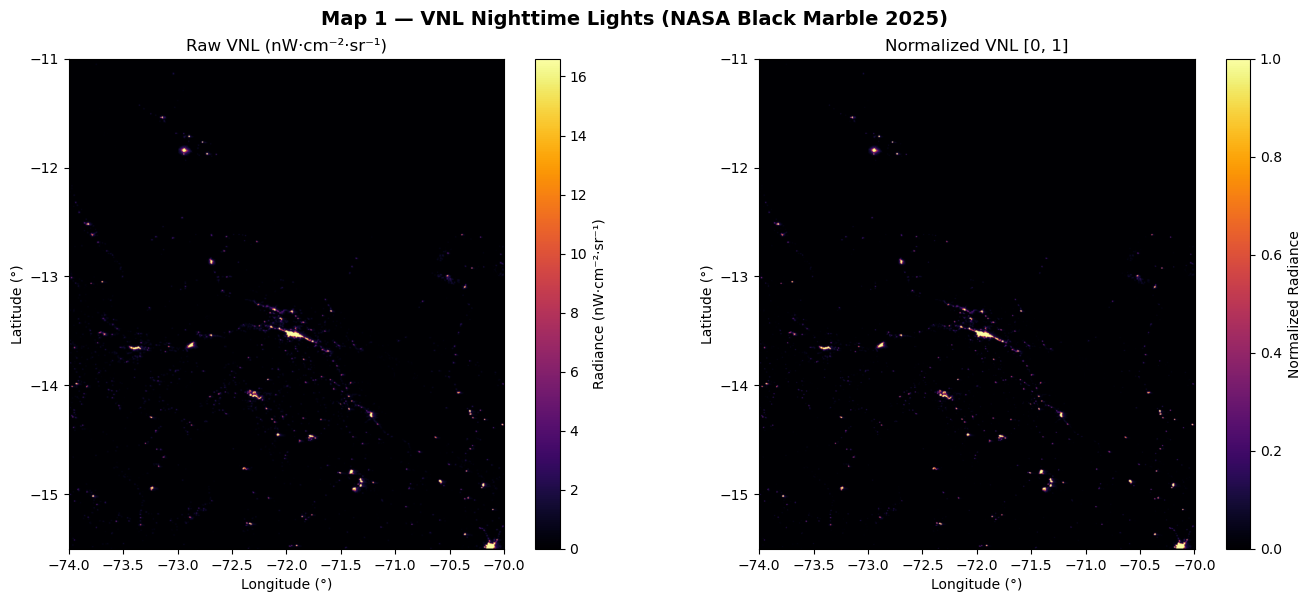


📌 Observación: Las zonas brillantes corresponden a los centros urbanos más poblados de la región Cusco (principalmente la ciudad de Cusco y distritos aledaños). Los valores altos de radiancia nocturna indican mayor electrificación y actividad económica. Las zonas oscuras representan áreas rurales y de alta montaña con mínima presencia de infraestructura humana.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 1 — VNL Nighttime Lights (NASA Black Marble 2025)",
             fontsize=14, fontweight="bold")

vmax_raw = float(np.percentile(vnl_arr[vnl_arr > 0], 98))

im1 = axes[0].imshow(vnl_arr, cmap="inferno", extent=extent,
                     origin="upper", vmin=0, vmax=vmax_raw)
axes[0].set_title("Raw VNL (nW·cm⁻²·sr⁻¹)")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[0], label="Radiance (nW·cm⁻²·sr⁻¹)")

im2 = axes[1].imshow(vnl_norm, cmap="inferno", extent=extent,
                     origin="upper", vmin=0, vmax=1)
axes[1].set_title("Normalized VNL [0, 1]")
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im2, ax=axes[1], label="Normalized Radiance")

plt.tight_layout()
plt.savefig("../output/map1_vnl.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 Observación: Las zonas brillantes corresponden a los centros urbanos más "
      "poblados de la región Cusco (principalmente la ciudad de Cusco y distritos "
      "aledaños). Los valores altos de radiancia nocturna indican mayor electrificación "
      "y actividad económica. Las zonas oscuras representan áreas rurales y de alta "
      "montaña con mínima presencia de infraestructura humana.")

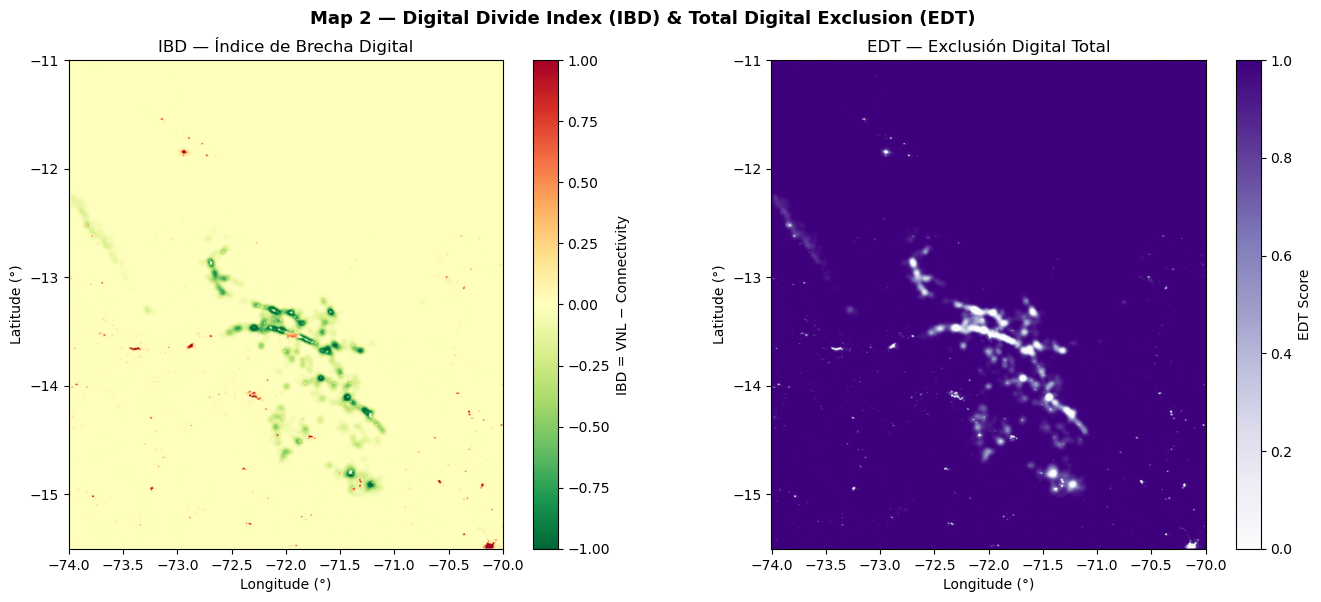


📌 IBD: Las zonas en rojo (IBD > 0) indican áreas con alta luminosidad nocturna pero baja cobertura móvil — aquí viven poblaciones con actividad económica pero sin acceso digital. Las zonas verdes (IBD < 0) están relativamente bien conectadas.

📌 EDT: Las zonas púrpuras (EDT → 1) representan territorios con ni electrificación ni conectividad — la exclusión más severa, que requiere inversión integral en infraestructura antes que soluciones de conectividad aisladas.


In [6]:
IBD = vnl_norm - conn_norm
EDT = (1 - vnl_norm) * (1 - conn_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 2 — Digital Divide Index (IBD) & Total Digital Exclusion (EDT)",
             fontsize=13, fontweight="bold")

im1 = axes[0].imshow(IBD, cmap="RdYlGn_r", extent=extent,
                     origin="upper", vmin=-1, vmax=1)
axes[0].set_title("IBD — Índice de Brecha Digital")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[0], label="IBD = VNL − Connectivity")

im2 = axes[1].imshow(EDT, cmap="Purples", extent=extent,
                     origin="upper", vmin=0, vmax=1)
axes[1].set_title("EDT — Exclusión Digital Total")
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im2, ax=axes[1], label="EDT Score")

plt.tight_layout()
plt.savefig("../output/map2_ibd_edt.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 IBD: Las zonas en rojo (IBD > 0) indican áreas con alta luminosidad nocturna "
      "pero baja cobertura móvil — aquí viven poblaciones con actividad económica pero "
      "sin acceso digital. Las zonas verdes (IBD < 0) están relativamente bien conectadas.")
print("\n📌 EDT: Las zonas púrpuras (EDT → 1) representan territorios con ni electrificación "
      "ni conectividad — la exclusión más severa, que requiere inversión integral en "
      "infraestructura antes que soluciones de conectividad aisladas.")

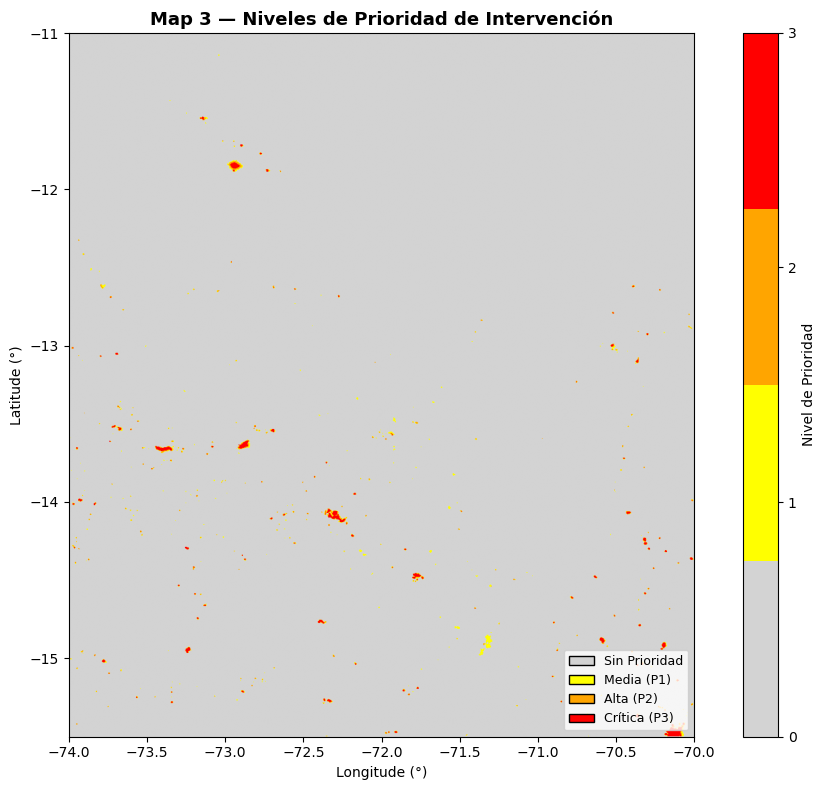


Nivel                   Píxeles   % del área
---------------------------------------------
Sin Prioridad         1,034,415       99.57%
Media (P1)                1,570        0.15%
Alta (P2)                 1,267        0.12%
Crítica (P3)              1,589        0.15%


In [7]:
priority = np.zeros_like(vnl_norm, dtype=np.uint8)
priority[(vnl_norm >= 0.10) & (conn_norm < 0.25)] = 1
priority[(vnl_norm >= 0.15) & (conn_norm < 0.15)] = 2
priority[(vnl_norm >= 0.30) & (conn_norm < 0.10)] = 3

labels   = {0: "Sin Prioridad", 1: "Media (P1)", 2: "Alta (P2)", 3: "Crítica (P3)"}
colors_p = ["lightgray", "yellow", "orange", "red"]
cmap_p   = mcolors.ListedColormap(colors_p)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(priority, cmap=cmap_p, extent=extent, origin="upper", vmin=0, vmax=3)
ax.set_title("Map 3 — Niveles de Prioridad de Intervención", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
legend_elems = [Patch(facecolor=c, edgecolor="black", label=l)
                for c, l in zip(colors_p, labels.values())]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
plt.colorbar(im, ax=ax, label="Nivel de Prioridad", ticks=[0, 1, 2, 3])
plt.tight_layout()
plt.savefig("../output/map3_priority.png", dpi=150, bbox_inches="tight")
plt.show()

total = priority.size
print(f"\n{'Nivel':<20} {'Píxeles':>10} {'% del área':>12}")
print("-" * 45)
for val, label in labels.items():
    count = int(np.sum(priority == val))
    pct   = count / total * 100
    print(f"{label:<20} {count:>10,} {pct:>11.2f}%")

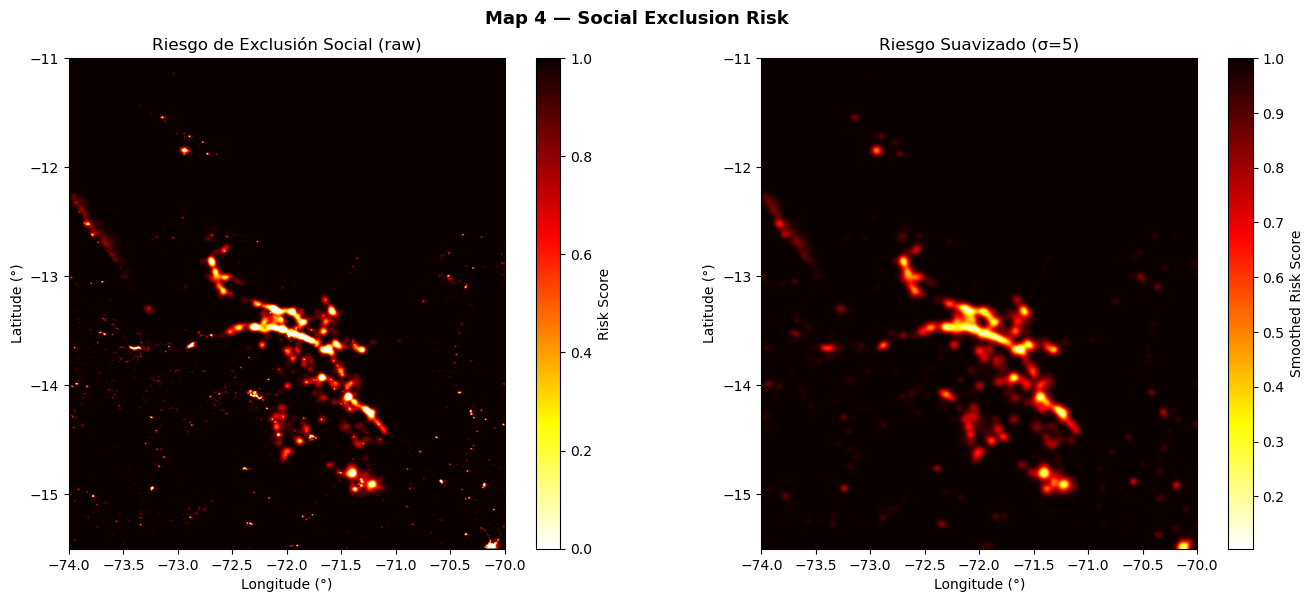


Umbral percentil 75: 1.0000
Umbral percentil 90: 1.0000


In [8]:
risk_raw    = EDT * (1 - vnl_norm)
rmin, rmax  = risk_raw.min(), risk_raw.max()
risk_norm   = (risk_raw - rmin) / (rmax - rmin + 1e-10)
risk_smooth = gaussian_filter(risk_norm, sigma=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Map 4 — Social Exclusion Risk", fontsize=13, fontweight="bold")

im1 = axes[0].imshow(risk_norm, cmap="hot_r", extent=extent,
                     origin="upper", vmin=0, vmax=1)
axes[0].set_title("Riesgo de Exclusión Social (raw)")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im1, ax=axes[0], label="Risk Score")

im2 = axes[1].imshow(risk_smooth, cmap="hot_r", extent=extent, origin="upper")
axes[1].set_title("Riesgo Suavizado (σ=5)")
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")
plt.colorbar(im2, ax=axes[1], label="Smoothed Risk Score")

plt.tight_layout()
plt.savefig("../output/map4_exclusion_risk.png", dpi=150, bbox_inches="tight")
plt.show()

p75 = float(np.percentile(risk_norm, 75))
p90 = float(np.percentile(risk_norm, 90))
print(f"\nUmbral percentil 75: {p75:.4f}")
print(f"Umbral percentil 90: {p90:.4f}")

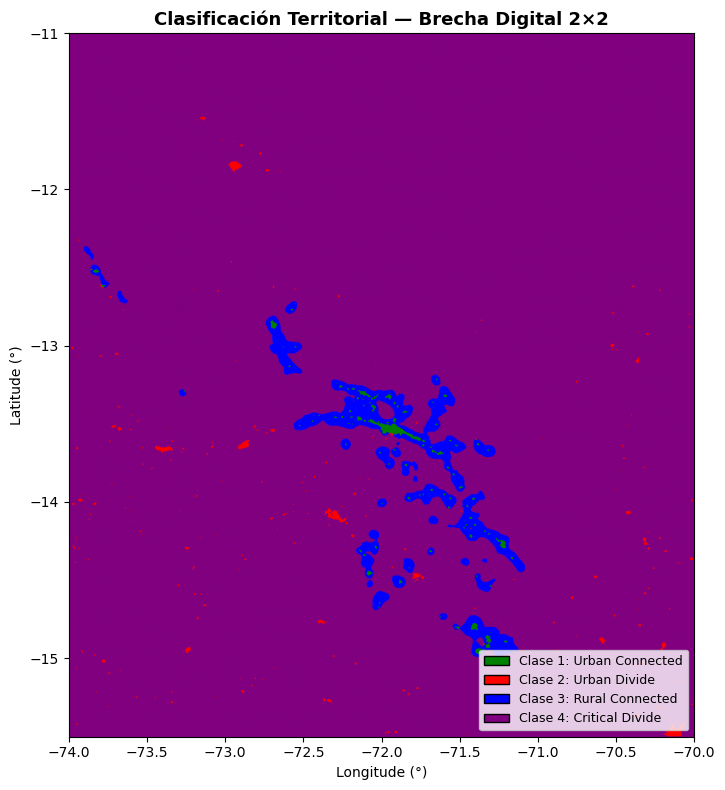

 Clase          Nombre  Píxeles  % Área  Área (km²)
     1 Urban Connected     2098    0.20      436.38
     2    Urban Divide     2856    0.27      594.04
     3 Rural Connected    26543    2.56     5520.84
     4 Critical Divide  1007344   96.97   209523.53

✅ Guardado: output/clasificacion_brecha.tif


In [9]:
clases = np.zeros_like(vnl_norm, dtype=np.uint8)
high_vnl  = vnl_norm  >= 0.15
high_conn = conn_norm >= 0.15

clases[ high_vnl &  high_conn] = 1
clases[ high_vnl & ~high_conn] = 2
clases[~high_vnl &  high_conn] = 3
clases[~high_vnl & ~high_conn] = 4

class_info = {
    1: ("Urban Connected",  "green"),
    2: ("Urban Divide",     "red"),
    3: ("Rural Connected",  "blue"),
    4: ("Critical Divide",  "purple"),
}

cmap_c   = mcolors.ListedColormap(["white", "green", "red", "blue", "purple"])
bounds_c = [0, 1, 2, 3, 4, 5]
norm_c   = mcolors.BoundaryNorm(bounds_c, cmap_c.N)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clases, cmap=cmap_c, norm=norm_c, extent=extent, origin="upper")
ax.set_title("Clasificación Territorial — Brecha Digital 2×2",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
legend_elems = [Patch(facecolor=info[1], edgecolor="black",
                      label=f"Clase {k}: {info[0]}")
                for k, info in class_info.items()]
ax.legend(handles=legend_elems, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../output/clasificacion_brecha_preview.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen
lat_cusco = -13.5
with rasterio.open(VNL_PATH) as src:
    rx, ry = src.res
km_per_lon = 111 * np.cos(np.radians(lat_cusco))
px_km2 = rx * km_per_lon * ry * 111

records = []
total_px = clases.size
for k, (name, _) in class_info.items():
    cnt  = int(np.sum(clases == k))
    pct  = cnt / total_px * 100
    area = cnt * px_km2
    records.append({"Clase": k, "Nombre": name,
                    "Píxeles": cnt, "% Área": round(pct, 2),
                    "Área (km²)": round(area, 2)})

df_clases = pd.DataFrame(records)
print(df_clases.to_string(index=False))

# Guardar raster
with rasterio.open(VNL_PATH) as src:
    profile = src.profile.copy()
profile.update(dtype=rasterio.uint8, count=1, nodata=0)
with rasterio.open("../output/clasificacion_brecha.tif", "w", **profile) as dst:
    dst.write(clases, 1)
print("\n✅ Guardado: output/clasificacion_brecha.tif")

         Estadísticas Descriptivas por Clase Territorial         

  Clase 1 — Urban Connected (n=2,098)
    VNL  — mean:0.5179 std:0.3256 min:0.1500 max:1.0000
    Conn — mean:0.6553 std:0.3065 min:0.1503 max:0.9999
    IBD  — mean:-0.1374 std:0.4283 min:-0.8497 max:0.8435

  Clase 2 — Urban Divide (n=2,856)
    VNL  — mean:0.4807 std:0.3129 min:0.1502 max:1.0000
    Conn — mean:0.0059 std:0.0228 min:0.0000 max:0.1487
    IBD  — mean:0.4748 std:0.3152 min:0.0075 max:1.0000

  Clase 3 — Rural Connected (n=26,543)
    VNL  — mean:0.0146 std:0.0268 min:0.0000 max:0.1499
    Conn — mean:0.3939 std:0.2392 min:0.1500 max:0.9999
    IBD  — mean:-0.3794 std:0.2318 min:-0.9999 max:-0.0108

  Clase 4 — Critical Divide (n=1,007,344)
    VNL  — mean:0.0008 std:0.0066 min:0.0000 max:0.1499
    Conn — mean:0.0029 std:0.0152 min:0.0000 max:0.1500
    IBD  — mean:-0.0021 std:0.0162 min:-0.1500 max:0.1499

Correlación de Pearson (VNL vs Conectividad, n=25,972):
  r = 0.3129  |  p-value = 0.00e+00


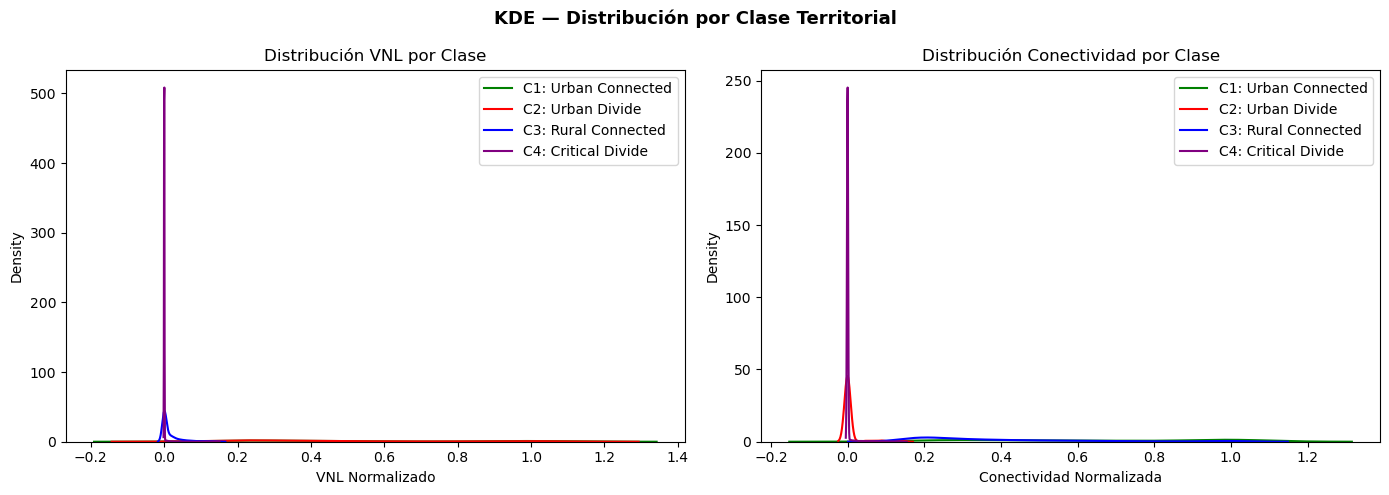


Welch t-test — VNL: Urban Connected vs Critical Divide:
  t-estadístico: 22.6233
  p-value:       4.24e-58
  Cohen's d:     2.2127


In [10]:
flat_vnl   = vnl_norm.ravel()
flat_conn  = conn_norm.ravel()
flat_ibd   = IBD.ravel()
flat_class = clases.ravel()

# Estadísticas descriptivas por clase
print(f"{'Estadísticas Descriptivas por Clase Territorial':^65}")
for k, (name, _) in class_info.items():
    mask = flat_class == k
    if mask.sum() == 0:
        continue
    v = flat_vnl[mask]; c = flat_conn[mask]; i = flat_ibd[mask]
    print(f"\n  Clase {k} — {name} (n={mask.sum():,})")
    print(f"    VNL  — mean:{v.mean():.4f} std:{v.std():.4f} min:{v.min():.4f} max:{v.max():.4f}")
    print(f"    Conn — mean:{c.mean():.4f} std:{c.std():.4f} min:{c.min():.4f} max:{c.max():.4f}")
    print(f"    IBD  — mean:{i.mean():.4f} std:{i.std():.4f} min:{i.min():.4f} max:{i.max():.4f}")

# Correlación de Pearson
r_vnl  = flat_vnl[::40]
r_conn = flat_conn[::40]
r, p   = stats.pearsonr(r_vnl, r_conn)
print(f"\nCorrelación de Pearson (VNL vs Conectividad, n={len(r_vnl):,}):")
print(f"  r = {r:.4f}  |  p-value = {p:.2e}")

# KDE por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KDE — Distribución por Clase Territorial", fontsize=13, fontweight="bold")
kde_colors = {1: "green", 2: "red", 3: "blue", 4: "purple"}

for k, (name, _) in class_info.items():
    mask = flat_class == k
    if mask.sum() < 200:
        continue
    sns.kdeplot(flat_vnl[mask][::10],  ax=axes[0], label=f"C{k}: {name}", color=kde_colors[k])
    sns.kdeplot(flat_conn[mask][::10], ax=axes[1], label=f"C{k}: {name}", color=kde_colors[k])

axes[0].set_title("Distribución VNL por Clase")
axes[0].set_xlabel("VNL Normalizado")
axes[0].legend()
axes[1].set_title("Distribución Conectividad por Clase")
axes[1].set_xlabel("Conectividad Normalizada")
axes[1].legend()
plt.tight_layout()
plt.savefig("../output/kde_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Welch t-test: Clase 1 vs Clase 4
v1 = flat_vnl[flat_class == 1][::10]
v4 = flat_vnl[flat_class == 4][::10]
t_stat, p_welch = stats.ttest_ind(v1, v4, equal_var=False)
pooled_std = np.sqrt((v1.std()**2 + v4.std()**2) / 2)
cohen_d = (v1.mean() - v4.mean()) / pooled_std

print(f"\nWelch t-test — VNL: Urban Connected vs Critical Divide:")
print(f"  t-estadístico: {t_stat:.4f}")
print(f"  p-value:       {p_welch:.2e}")
print(f"  Cohen's d:     {cohen_d:.4f}")

Exportando rasters procesados...
  ✅ ../output/vnl_norm.tif
  ✅ ../output/conn_norm.tif
  ✅ ../output/ibd_brecha_digital.tif


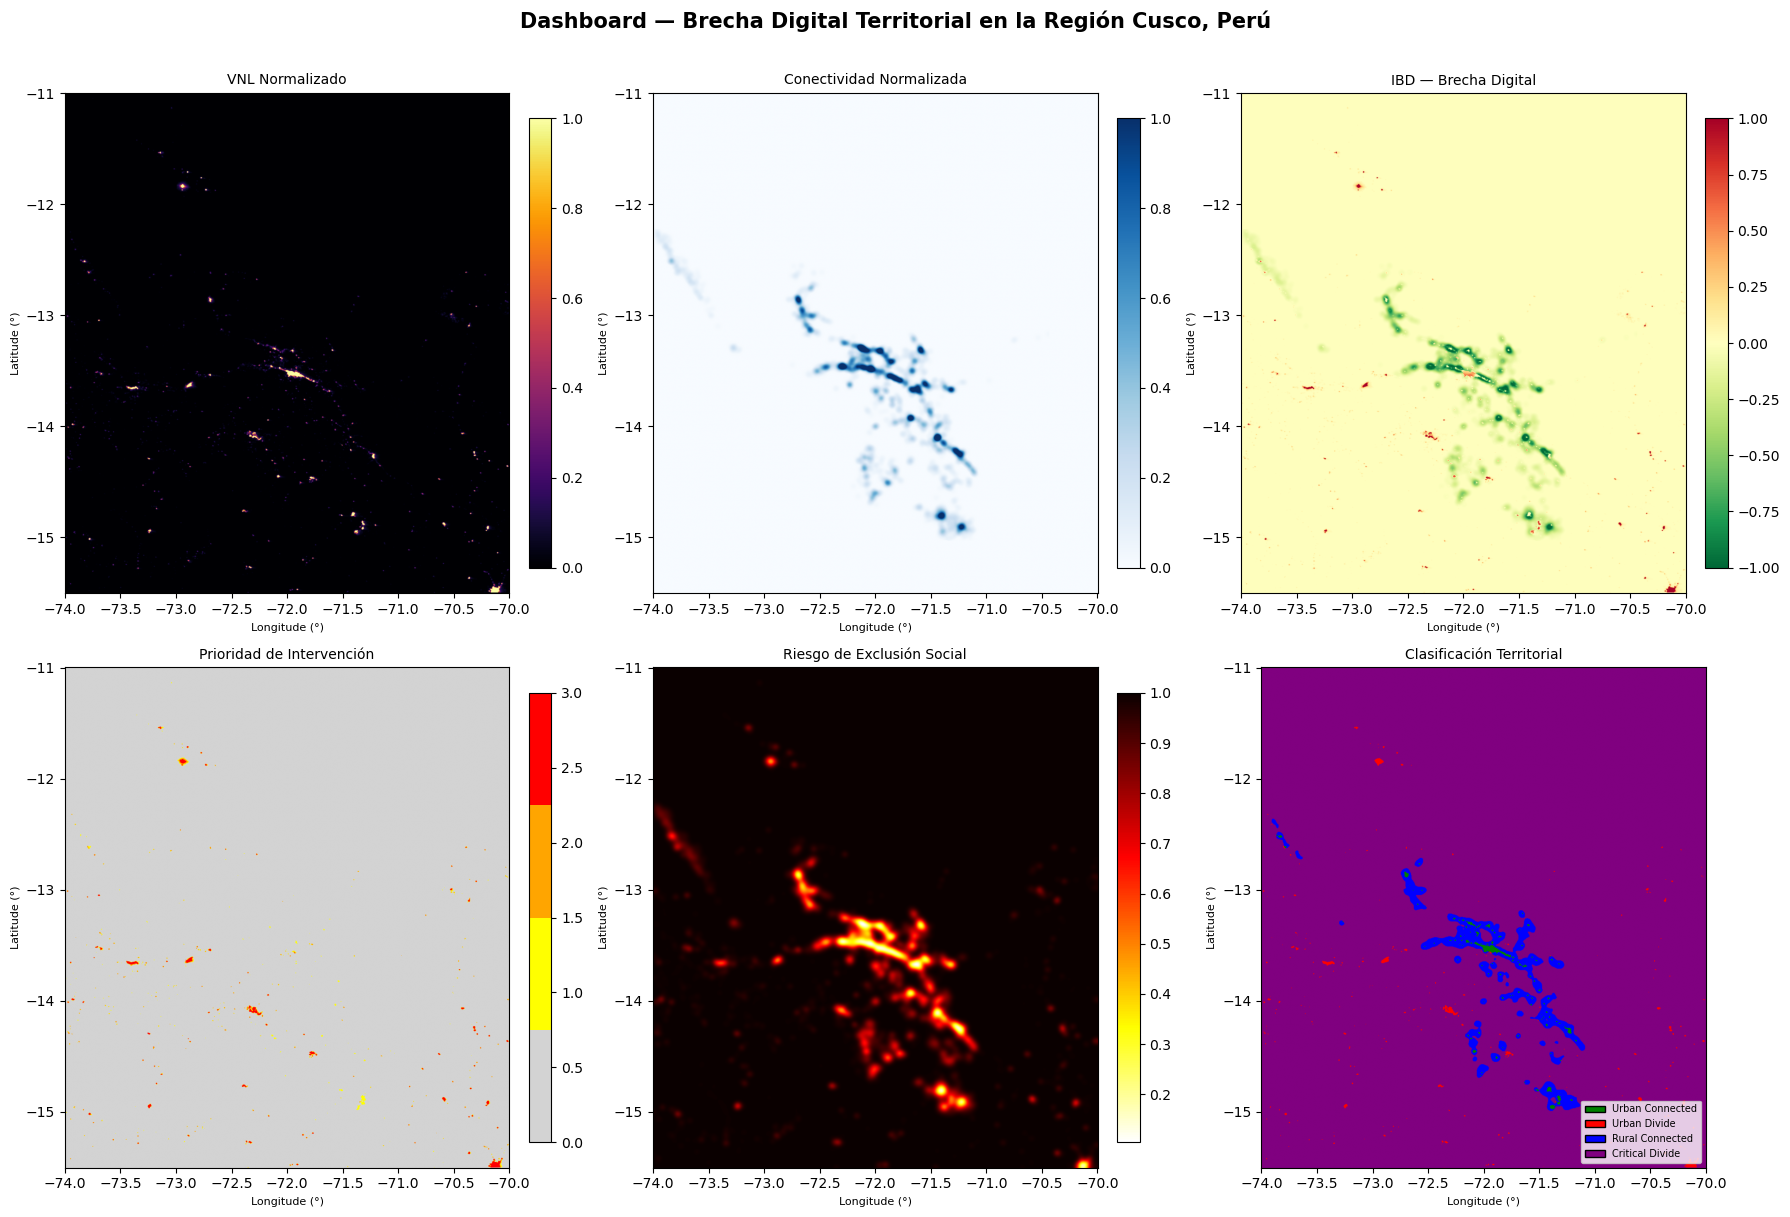


✅ Dashboard guardado: output/dashboard_brecha_digital.png


In [11]:
def save_raster(arr, path, ref_path, dtype="float32"):
    with rasterio.open(ref_path) as ref:
        profile = ref.profile.copy()
    profile.update(dtype=dtype, count=1, nodata=-9999)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr.astype(dtype), 1)
    print(f"  ✅ {path}")

print("Exportando rasters procesados...")
save_raster(vnl_norm,  "../output/vnl_norm.tif",          VNL_PATH)
save_raster(conn_norm, "../output/conn_norm.tif",          VNL_PATH)
save_raster(IBD,       "../output/ibd_brecha_digital.tif", VNL_PATH)

# Dashboard final
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Dashboard — Brecha Digital Territorial en la Región Cusco, Perú",
             fontsize=15, fontweight="bold", y=1.01)

def add_map(ax, data, cmap, title, vmin=None, vmax=None):
    im = ax.imshow(data, cmap=cmap, extent=extent, origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude (°)", fontsize=8)
    ax.set_ylabel("Latitude (°)", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

add_map(axes[0,0], vnl_norm,   "inferno",  "VNL Normalizado",          vmin=0, vmax=1)
add_map(axes[0,1], conn_norm,  "Blues",    "Conectividad Normalizada",  vmin=0, vmax=1)
add_map(axes[0,2], IBD,        "RdYlGn_r", "IBD — Brecha Digital",     vmin=-1, vmax=1)
add_map(axes[1,0], priority,   cmap_p,     "Prioridad de Intervención", vmin=0, vmax=3)
add_map(axes[1,1], risk_smooth,"hot_r",    "Riesgo de Exclusión Social")

im_c = axes[1,2].imshow(clases, cmap=cmap_c, norm=norm_c, extent=extent, origin="upper")
axes[1,2].set_title("Clasificación Territorial", fontsize=10)
axes[1,2].set_xlabel("Longitude (°)", fontsize=8)
axes[1,2].set_ylabel("Latitude (°)", fontsize=8)
legend_elems = [Patch(facecolor=info[1], edgecolor="black", label=info[0])
                for k, info in class_info.items()]
axes[1,2].legend(handles=legend_elems, loc="lower right", fontsize=7)

plt.tight_layout()
plt.savefig("../output/dashboard_brecha_digital.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Dashboard guardado: output/dashboard_brecha_digital.png")